# Lecture 14: Numerical solution of ODEs continued
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/natrask/engr1050-fall2026/blob/main/NewMaterial/Lecture13_Oct12/lec13.ipynb)


## To get started

In last lecture we built a class which implements explicit Euler to numerically solve ODEs, and then went through best practices of how to do that. Today I'm going to give a bit more explicit direction on how to go about using that code, and we'll get some practice using inheritance in the process.

# Problem statement

Today we will set the code up to solve both a scalar and a vector ODE. You will notice that these are very close to the ones you need in HW3; these are the nonlinear versions of the linear problems in HW3.

**ODE1: (Exponential decay with source)**
$$ \dot{y_1} = -\frac {k}{m} y_1^2 + g$$

**ODE2: (Nonlinear pendulum equation)**
$$ \dot{y_1} = y_2 $$
$$ \dot{y_2} = - \frac{g}{L} \sin \left(y_1\right)$$

# Build the `ODE_solver` class

I'm copying over the class that we built together in last Wednesday's lecture:

ODE_solver initialized!
The error between the numerical and analytic solution is 0.2741051707557682


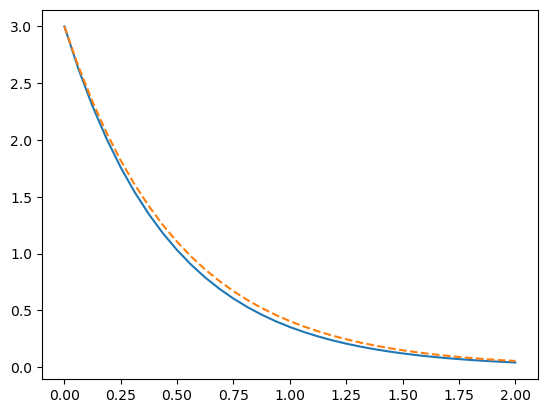

In [18]:
import numpy as np

class ODE_solver:
    def __init__(self, t0, tf, y0, N):
        self.y0 = y0    # initial condition (should be a numpy array)
        self.t0 = t0    # initial time
        self.tf = tf    # final time
        self.N = N      # number of steps
        self.h = (tf - t0) / float(N) # step size, calculated from inputs

        # We need to check what size y0 is and store that information to size the solution array
        self.dim = len(y0) #assumes that y0 is a list or array

        # Create a place to store the solution
        self.t_values = np.array([t0 + i*self.h for i in range(N+1)])  # time values
        self.solution = np.zeros((N+1, self.dim))  # solution array
        self.solution[0, :] = y0  # set initial condition

        print(f"{self.__class__.__name__} initialized!")  # success
        
    def f(self,t,y):
        # Define the right-hand side of the ODE here, assuming a scalar t and a numpy array y
        # Example: dy/dt = -2y (for scalar y),
        # this function should return a numpy array of the same shape as y
        f = np.zeros(self.dim) # use self.dim to match shape of y
        f[0] = -2 * y[0]  # Example for the first component
        return f
    
    def solve(self):
        for n in range(self.N):
            t_n = self.t_values[n]
            y_n = self.solution[n, :]
            f_n = self.f(t_n, y_n)
            self.solution[n+1, :] = y_n + self.h * f_n
        return self.solution

# Instantiate the ODE_solver
Nsteps = 32
mySolve = ODE_solver(0, 2, [3], Nsteps)
t_values = mySolve.t_values
solution = mySolve.solve()

# Plot an analytic solution
t_analytic = np.linspace(0, 2, Nsteps+1)
analytic = 3 * np.exp(-2 * np.array(t_analytic))

import matplotlib.pyplot as plt
plt.plot(t_values, solution[:, 0], label='y1(t)')
plt.plot(t_analytic, analytic, label='Analytic y1(t)', linestyle='dashed')

print(f'The error between the numerical and analytic solution is {np.linalg.norm(solution[:,0] - analytic[:])}')

# Using inheritance

The two ODEs that we want to solve use this class identically - we *could* just copy and paste the class twice and define sometihng like `ODE_solver1` and `ODE_solver2`. Instead we're going to do something more elegant. Note that the only change needed between the two classes is a different RHS. The following will *overload* the `f` function into new derived child classes, keeping the rest of the class the same.

In [19]:
class SkyDiver_ODE(ODE_solver): # Inherit from ODE_solver, so all methods and properties are available
    def f(self, t, y):
        g = 9.81  # m/s^2
        c = 0.25  # drag coefficient
        m = 68.1  # mass in kg
        f = np.zeros(self.dim)
        f[0] = g - (c/m) * y[0]**2
        return f
    
class Pendulum_ODE(ODE_solver):
    def f(self, t, y):
        g = 9.81  # m/s^2
        L = 1.0   # length in meters of pendulum bar
        f = np.zeros(2)
        f[0] = y[1]
        f[1] = -(g/L) * np.sin(y[0])
        return f

Let's remember back when we were learning about classes. We don't need a new initializer, because all of the variables for this class are the same (nothing new to initialize!). That means we don't need to use the `super` stuff. All we need to do is overload `f` to specialize the class to different kinds of ODEs.

SkyDiver_ODE initialized!


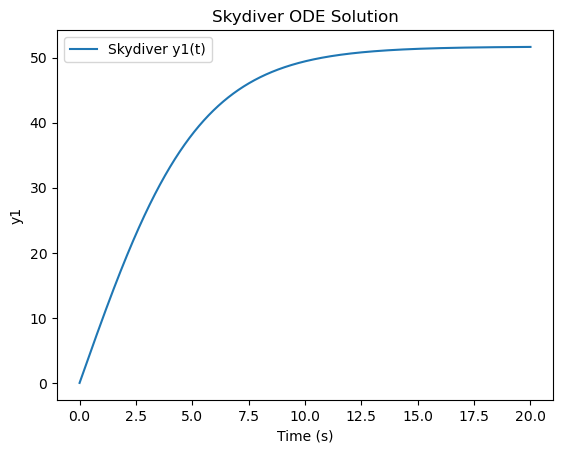

In [ ]:
# Solve the skydiver ODE
Nsteps_sd = 3200
skydiver = SkyDiver_ODE(0, 20, [0], Nsteps_sd) # Note that the initial condition is written as a list with one element
sd_t = skydiver.t_values
sd_sol = skydiver.solve()

# Plot results
plt.plot(sd_t, sd_sol[:, 0], label='Skydiver y1(t)')
plt.title('Skydiver ODE Solution')
plt.xlabel('Time (s)')
plt.ylabel('y1')
plt.legend()

Pendulum_ODE initialized!


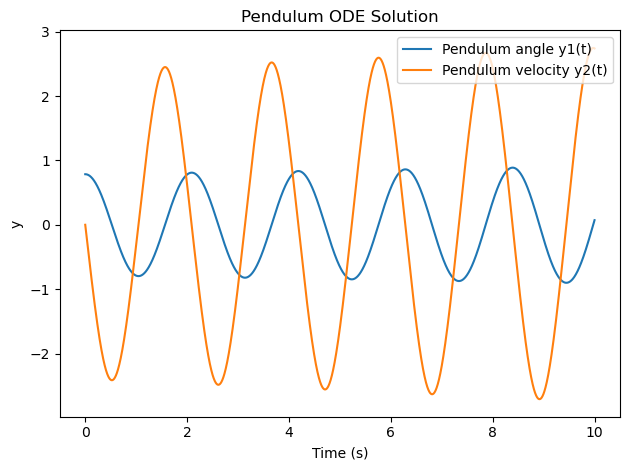

In [21]:
# Solve the pendulum ODE
Nsteps_pend = 3200
pendulum = Pendulum_ODE(0, 10, [np.pi/4, 0], Nsteps_pend)
pend_t = pendulum.t_values
pend_sol = pendulum.solve()

# Plot results
plt.plot(pend_t, pend_sol[:, 0], label='Pendulum angle y1(t)')
plt.plot(pend_t, pend_sol[:, 1], label='Pendulum velocity y2(t)')
plt.title('Pendulum ODE Solution')
plt.xlabel('Time (s)')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()

## Building trust in your simulations

Every time you run a simulation, you *must* check that it gives a reasonable result. You're far enough into your Python journey that you know how easy it is for a minus sign to pop up in the wrong spot. While we're doing toy ODEs right now, as you do more serious engineering these simulations will govern the strength of a bridge or a part of an airplane; for high-consequence problems with peoples lives on the line, a major part of simulation is how to tell whether you can trust the prediction.

### Convergence

Run the code for increasingly large N until you converge. Don't do $N = 1,2,3,4...$, do large increments $N = 10,100,1000...$

Initialized
Initialized
Initialized
Initialized
N=100, final angle=-46.42407744319916
N=1000, final angle=-0.6144751203735287
N=10000, final angle=0.1770957109730522
N=100000, final angle=0.21025063859212145


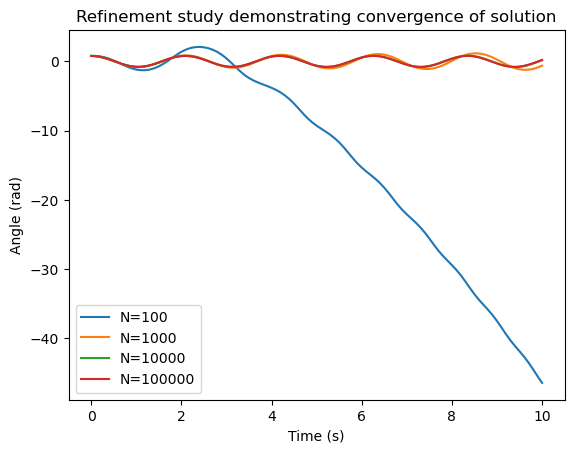

In [17]:
node_counts = [100,1000,10000,100000]
pendulum_solutions = {}
pendulum_times = {}

for N in node_counts:
    pend = Pendulum_ODE(0, 10, [np.pi/4, 0], N)
    pendulum_solutions[N] = pend.solve()
    pendulum_times[N] = pend.t_values

# Example: print the final angle for each node count
for N in node_counts:
    print(f"N={N}, final angle={pendulum_solutions[N][-1,0]}")
    plt.plot(pendulum_times[N], pendulum_solutions[N][:,0], label=f'N={N}')
plt.title('Refinement study demonstrating convergence of solution')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.legend()
plt.show()

### Asymptotic behavior

For nonlinear problems, it is in general not possible to work out what the analytic solution to the ODE is (if it were possible, we'd solve it on paper and not on a computer!). So we 

# Submit today's work #
Today is set aside for you to complete HW3 - with the fall break last week I wanted to make sure that nobody slips behind. We will need to use the simulations that we put together today to do the helicopter lab, so make sure you fully understand everything and take advantage of lecture today as a "virtual office hour".

1. Make sure you have a working code, and you have used the analytic solution to ensure that it was properly implemented.
4. Go to the [Canvas homework assignment page](https://canvas.upenn.edu/courses/1881448/assignments/14014984) to find HW3. 
5. Generate a **new jupyter notebook** that completes the homework assignment and upload to canvas.
6. Use the extra time in class today to finish the homework and ask us questions.